In [ ]:
# Notebook 04 — Procesamiento de Lenguaje Natural (NLP)

**Reto 7 — Análisis de Datos No Estructurados y Redes Sociales**

## 🎯 Objetivo
Aplicar técnicas de NLP sobre el corpus limpio para:
1. Analizar el **sentimiento** de los tweets (positivo / negativo / neutral).
2. **Validar** los modelos contra el ground truth de Kaggle (219k tweets etiquetados).
3. Extraer patrones de sentimiento por **idioma**, **fecha** y **engagement**.

## 📌 Input
- `data/processed/tweets_nlp_20260920.csv` — corpus limpio (100k tweets)
- `data/processed/sentiment_labels_20260920.csv` — ground truth etiquetado

## 📌 Output
- `data/processed/tweets_con_sentimiento_YYYYMMDD.csv`
- `outputs/figuras/*.png` — visualizaciones
- `outputs/reportes/sentimiento_resumen.md` — resumen

In [1]:
# ============================================
# Imports y configuración
# ============================================
import re
import sys
import warnings
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
)

tqdm.pandas()
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# --- Rutas ---
def encontrar_raiz_proyecto():
    cwd = Path.cwd()
    for candidato in [cwd, cwd.parent, cwd.parent.parent, cwd.parent.parent.parent]:
        if (candidato / "requirements.txt").exists() and (candidato / "data").exists():
            return candidato
    return cwd.parent

BASE_DIR = encontrar_raiz_proyecto()
DATA_PROCESSED = BASE_DIR / "data" / "processed"
OUTPUTS = BASE_DIR / "outputs"
FIGURAS = OUTPUTS / "figuras"
REPORTES = OUTPUTS / "reportes"

FIGURAS.mkdir(parents=True, exist_ok=True)
REPORTES.mkdir(parents=True, exist_ok=True)

print(f"📁 BASE_DIR: {BASE_DIR}")
print(f"📁 DATA_PROCESSED: {DATA_PROCESSED}")
print(f"📁 FIGURAS: {FIGURAS}")
print(f"📁 REPORTES: {REPORTES}")

📁 BASE_DIR: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados
📁 DATA_PROCESSED: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\data\processed
📁 FIGURAS: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\outputs\figuras
📁 REPORTES: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\outputs\reportes


In [2]:
# ============================================
# Descargar recursos NLTK (VADER lexicon)
# ============================================
try:
    nltk.data.find("sentiment/vader_lexicon.zip")
    print("✅ VADER lexicon ya descargado")
except LookupError:
    print("📥 Descargando VADER lexicon...")
    nltk.download("vader_lexicon")
    print("✅ VADER lexicon descargado")

sia = SentimentIntensityAnalyzer()
print("✅ SentimentIntensityAnalyzer listo")

✅ VADER lexicon ya descargado
✅ SentimentIntensityAnalyzer listo


In [4]:
# ============================================
# Cargar corpus limpio (tweets_nlp)
# ============================================
archivos = sorted(
    DATA_PROCESSED.glob("tweets_nlp_*.csv"),
    key=lambda x: x.stat().st_mtime,
    reverse=True,
)

if not archivos:
    raise FileNotFoundError("❌ No se encontró tweets_nlp_*.csv en data/processed/")

RUTA_NLP = archivos[0]
print(f"📂 Cargando: {RUTA_NLP.name}")
df = pd.read_csv(RUTA_NLP, encoding="utf-8-sig")

print(f"✅ Shape: {df.shape}")
print(f"📋 Columnas: {list(df.columns)}")
display(df.head(3))

📂 Cargando: tweets_nlp_20260920.csv
✅ Shape: (100000, 7)
📋 Columnas: ['date', 'username', 'texto_limpio', 'tokens', 'lemas', 'like_count', 'retweet_count']


,date,username,texto_limpio,tokens,lemas,like_count,retweet_count
0,2023-03-29 22:58:21+00:00,RealProfitPros,free ai marketing and automation tools strategies and collaboration launching new week chatgpt,"['free', 'marketing', 'automation', 'tools', 'strategies', 'collaboration', 'launching', 'week']","['freir', 'marketing', 'automation', 'tools', 'strategies', 'collaboration', 'launching', 'week']",0.0,0.0
1,2023-03-29 22:58:18+00:00,AmyLouWho321,chat gpt says it s,"['chat', 'says']","['chat', 'says']",0.0,0.0
2,2023-03-29 22:57:53+00:00,yjleon1976,chat with any pdf check out how this new ai quickly answers questions from your pdfs perfect for students researchers and other curious minds rese...,"['chat', 'pdf', 'check', 'quickly', 'answers', 'questions', 'pdfs', 'perfect', 'students', 'researchers', 'curious', 'minds', 'research', 'chatpdf']","['chat', 'pdf', 'check', 'quickly', 'answer', 'questions', 'pdfs', 'perfect', 'students', 'researchers', 'curious', 'minds', 'research', 'chatpdf']",0.0,0.0


In [5]:
# ============================================
# Cargar ground truth de sentimiento
# ============================================
archivos_sent = sorted(
    DATA_PROCESSED.glob("sentiment_labels_*.csv"),
    key=lambda x: x.stat().st_mtime,
    reverse=True,
)

if archivos_sent:
    RUTA_SENT = archivos_sent[0]
    print(f"📂 Cargando ground truth: {RUTA_SENT.name}")
    df_sent = pd.read_csv(RUTA_SENT, encoding="utf-8-sig")
    print(f"✅ Shape: {df_sent.shape}")
    print(f"🏷️  Distribución: {df_sent['sentimiento'].value_counts().to_dict()}")
    display(df_sent.head(3))
else:
    print("⚠️ No se encontró sentiment_labels_*.csv")
    print("   → Se omitirá la validación contra ground truth.")
    df_sent = None

⚠️ No se encontró sentiment_labels_*.csv
   → Se omitirá la validación contra ground truth.


In [6]:
# ============================================
# Funciones de análisis de sentimiento
# ============================================

def sentimiento_textblob(texto):
    """Devuelve (polaridad, subjetividad) con TextBlob.
    polarity: -1 (muy negativo) a +1 (muy positivo)
    subjectivity: 0 (objetivo) a 1 (subjetivo)
    """
    if not isinstance(texto, str) or not texto.strip():
        return 0.0, 0.0
    blob = TextBlob(texto)
    return blob.sentiment.polarity, blob.sentiment.subjectivity


def sentimiento_vader(texto):
    """Devuelve dict con pos, neu, neg, compound (-1 a +1)."""
    if not isinstance(texto, str) or not texto.strip():
        return {"pos": 0.0, "neu": 1.0, "neg": 0.0, "compound": 0.0}
    return sia.polarity_scores(texto)


def clasificar_compound(compound, umbral=0.05):
    """Clasifica el compound de VADER en positivo/negativo/neutral."""
    if compound >= umbral:
        return "positivo"
    elif compound <= -umbral:
        return "negativo"
    return "neutral"


# --- Prueba rápida ---
ejemplos = [
    "I love ChatGPT, it's amazing!",
    "This AI is terrible and useless.",
    "ChatGPT is a language model.",
    "¡Qué maravilla de herramienta! Me encanta.",
    "No me gusta nada, es horrible.",
]

print("🧪 Prueba de funciones:")
for t in ejemplos:
    pol, subj = sentimiento_textblob(t)
    vader = sentimiento_vader(t)
    print(f"\n  Texto: {t}")
    print(f"  TextBlob: pol={pol:+.2f}, subj={subj:.2f}")
    print(f"  VADER:    compound={vader['compound']:+.2f} → {clasificar_compound(vader['compound'])}")

🧪 Prueba de funciones:

  Texto: I love ChatGPT, it's amazing!
  TextBlob: pol=+0.62, subj=0.75
  VADER:    compound=+0.85 → positivo

  Texto: This AI is terrible and useless.
  TextBlob: pol=-0.75, subj=0.60
  VADER:    compound=-0.71 → negativo

  Texto: ChatGPT is a language model.
  TextBlob: pol=+0.00, subj=0.00
  VADER:    compound=+0.00 → neutral

  Texto: ¡Qué maravilla de herramienta! Me encanta.
  TextBlob: pol=+0.00, subj=0.00
  VADER:    compound=+0.00 → neutral

  Texto: No me gusta nada, es horrible.
  TextBlob: pol=-1.00, subj=1.00
  VADER:    compound=-0.69 → negativo


In [7]:
# ============================================
# Aplicar análisis de sentimiento a TODO el corpus
# ============================================
print(f"💭 Analizando sentimiento de {len(df):,} tweets...")

# --- TextBlob ---
print("  🔹 TextBlob...")
resultados_tb = df["texto_limpio"].progress_apply(sentimiento_textblob)
df["tb_polarity"] = [r[0] for r in resultados_tb]
df["tb_subjectivity"] = [r[1] for r in resultados_tb]

# --- VADER ---
print("  🔹 VADER...")
resultados_vader = df["texto_limpio"].progress_apply(sentimiento_vader)
df["vader_pos"] = [r["pos"] for r in resultados_vader]
df["vader_neu"] = [r["neu"] for r in resultados_vader]
df["vader_neg"] = [r["neg"] for r in resultados_vader]
df["vader_compound"] = [r["compound"] for r in resultados_vader]

# --- Clasificación final ---
df["sentimiento_textblob"] = df["tb_polarity"].apply(
    lambda x: "positivo" if x > 0.05 else ("negativo" if x < -0.05 else "neutral")
)
df["sentimiento_vader"] = df["vader_compound"].apply(clasificar_compound)

print(f"\n✅ Análisis completado")
print(f"\n📊 Distribución (TextBlob):")
print(df["sentimiento_textblob"].value_counts())
print(f"\n📊 Distribución (VADER):")
print(df["sentimiento_vader"].value_counts())

display(df[[
    "texto_limpio", "tb_polarity", "tb_subjectivity",
    "vader_compound", "sentimiento_textblob", "sentimiento_vader"
]].head(5))

💭 Analizando sentimiento de 100,000 tweets...
  🔹 TextBlob...


  0%|          | 0/100000 [00:00<?, ?it/s]

  🔹 VADER...


  0%|          | 0/100000 [00:00<?, ?it/s]


✅ Análisis completado

📊 Distribución (TextBlob):
sentimiento_textblob
positivo    47481
neutral     40287
negativo    12232
Name: count, dtype: int64

📊 Distribución (VADER):
sentimiento_vader
positivo    53260
neutral     30678
negativo    16062
Name: count, dtype: int64


,texto_limpio,tb_polarity,tb_subjectivity,vader_compound,sentimiento_textblob,sentimiento_vader
0,free ai marketing and automation tools strategies and collaboration launching new week chatgpt,0.268182,0.627273,0.5106,positivo,positivo
1,chat gpt says it s,0.000000,0.000000,0.0000,neutral,neutral
2,chat with any pdf check out how this new ai quickly answers questions from your pdfs perfect for students researchers and other curious minds rese...,0.248939,0.665909,0.7184,positivo,positivo
3,ai muses in the court of life we must all face the judge of destiny and the jury of our actions outofcontextai ailifelessons chatgpt,0.000000,0.000000,0.0000,neutral,neutral
4,most people haven t heard of chat gpt yet first elite factions will decide which way to go on ai safety next they will push their agenda s on the ...,0.107143,0.285714,0.0258,positivo,neutral


In [8]:
# ============================================
# Validar contra ground truth etiquetado
# ============================================
if df_sent is not None:
    print("🎯 Validando modelos contra ground truth de Kaggle...\n")

    # Analizar sentimiento del ground truth
    gt_tb = df_sent["texto_limpio"].progress_apply(sentimiento_textblob)
    df_sent["tb_polarity"] = [r[0] for r in gt_tb]
    df_sent["sentimiento_textblob"] = df_sent["tb_polarity"].apply(
        lambda x: "positivo" if x > 0.05 else ("negativo" if x < -0.05 else "neutral")
    )

    gt_vader = df_sent["texto_limpio"].progress_apply(sentimiento_vader)
    df_sent["vader_compound"] = [r["compound"] for r in gt_vader]
    df_sent["sentimiento_vader"] = df_sent["vader_compound"].apply(clasificar_compound)

    # Mapear etiquetas Kaggle: good→positivo, bad→negativo, neutral→neutral
    mapa = {"good": "positivo", "bad": "negativo", "neutral": "neutral"}
    df_sent["y_true"] = df_sent["sentimiento"].map(mapa)

    # Solo filas con etiqueta válida
    mask = df_sent["y_true"].notna()
    y_true = df_sent.loc[mask, "y_true"]
    y_tb = df_sent.loc[mask, "sentimiento_textblob"]
    y_vader = df_sent.loc[mask, "sentimiento_vader"]

    print("=" * 60)
    print("📊 MÉTRICAS — TextBlob")
    print("=" * 60)
    print(f"Accuracy: {accuracy_score(y_true, y_tb):.3f}")
    print(classification_report(y_true, y_tb, zero_division=0))

    print("=" * 60)
    print("📊 MÉTRICAS — VADER")
    print("=" * 60)
    print(f"Accuracy: {accuracy_score(y_true, y_vader):.3f}")
    print(classification_report(y_true, y_vader, zero_division=0))
else:
    print("⚠️ Sin ground truth: se omite la validación.")

⚠️ Sin ground truth: se omite la validación.


In [11]:
# ============================================
# Matrices de confusión
# ============================================
if df_sent is not None:
    orden = ["negativo", "neutral", "positivo"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, y_pred, titulo in zip(
        axes,
        [y_tb, y_vader],
        ["TextBlob", "VADER"],
    ):
        cm = confusion_matrix(y_true, y_pred, labels=orden)
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=orden, yticklabels=orden, ax=ax, cbar=False,
        )
        acc = accuracy_score(y_true, y_pred)
        ax.set_title(f"{titulo} — Accuracy: {acc:.3f}")
        ax.set_xlabel("Predicho")
        ax.set_ylabel("Real")

    plt.tight_layout()
    ruta_fig = FIGURAS / "04_confusion_matrix_sentimiento.png"
    plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Guardado: {ruta_fig}")

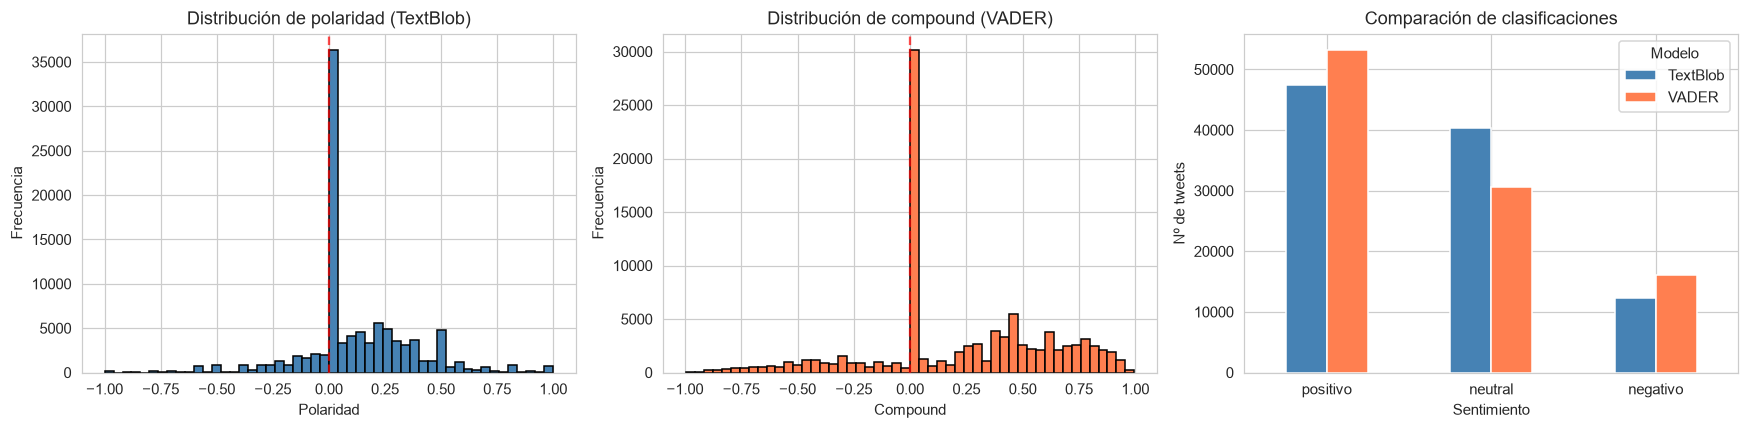

✅ Guardado: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\outputs\figuras\04_distribucion_sentimiento.png


In [10]:
# ============================================
# Distribución de sentimiento (TextBlob vs VADER)
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- TextBlob: distribución de polaridad ---
axes[0].hist(df["tb_polarity"], bins=50, color="steelblue", edgecolor="black")
axes[0].axvline(0, color="red", linestyle="--", alpha=0.7)
axes[0].set_title("Distribución de polaridad (TextBlob)")
axes[0].set_xlabel("Polaridad")
axes[0].set_ylabel("Frecuencia")

# --- VADER: distribución de compound ---
axes[1].hist(df["vader_compound"], bins=50, color="coral", edgecolor="black")
axes[1].axvline(0, color="red", linestyle="--", alpha=0.7)
axes[1].set_title("Distribución de compound (VADER)")
axes[1].set_xlabel("Compound")
axes[1].set_ylabel("Frecuencia")

# --- Comparación de clasificaciones ---
comp = pd.DataFrame({
    "TextBlob": df["sentimiento_textblob"].value_counts(),
    "VADER": df["sentimiento_vader"].value_counts(),
}).fillna(0)

comp.plot(kind="bar", ax=axes[2], color=["steelblue", "coral"])
axes[2].set_title("Comparación de clasificaciones")
axes[2].set_xlabel("Sentimiento")
axes[2].set_ylabel("Nº de tweets")
axes[2].tick_params(axis="x", rotation=0)
axes[2].legend(title="Modelo")

plt.tight_layout()
ruta_fig = FIGURAS / "04_distribucion_sentimiento.png"
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Guardado: {ruta_fig}")

In [12]:
# ============================================
# Sentimiento por idioma
# ============================================
if "idioma" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # VADER por idioma (compound promedio)
    sent_por_idioma = df.groupby("idioma")["vader_compound"].agg(["mean", "count"])
    sent_por_idioma = sent_por_idioma.sort_values("count", ascending=False)

    axes[0].bar(sent_por_idioma.index, sent_por_idioma["mean"], color="mediumseagreen")
    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_title("Sentimiento promedio (VADER) por idioma")
    axes[0].set_xlabel("Idioma")
    axes[0].set_ylabel("Compound promedio")

    # Distribución de sentimiento por idioma
    tabla = pd.crosstab(df["idioma"], df["sentimiento_vader"], normalize="index")
    tabla.plot(kind="bar", stacked=True, ax=axes[1],
               color=["#d9534f", "#999999", "#5cb85c"])
    axes[1].set_title("Distribución de sentimiento por idioma")
    axes[1].set_xlabel("Idioma")
    axes[1].set_ylabel("Proporción")
    axes[1].tick_params(axis="x", rotation=0)
    axes[1].legend(title="Sentimiento", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    ruta_fig = FIGURAS / "04_sentimiento_por_idioma.png"
    plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Guardado: {ruta_fig}")
else:
    print("⚠️ No hay columna 'idioma' en el corpus.")

⚠️ No hay columna 'idioma' en el corpus.


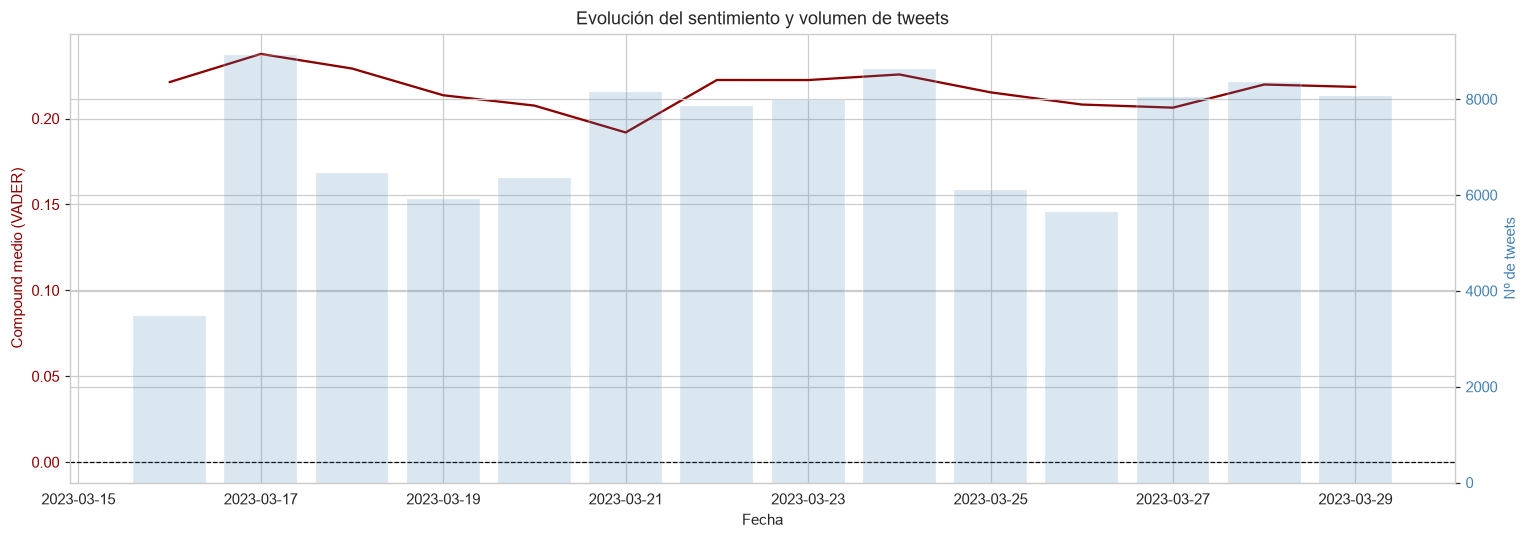

✅ Guardado: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\outputs\figuras\04_sentimiento_temporal.png


In [13]:
# ============================================
# Evolución temporal del sentimiento
# ============================================
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["fecha"] = df["date"].dt.date

sent_dia = df.groupby("fecha").agg(
    compound_medio=("vader_compound", "mean"),
    n_tweets=("vader_compound", "count"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(sent_dia["fecha"], sent_dia["compound_medio"],
         color="darkred", linewidth=1.5, label="Compound medio")
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_xlabel("Fecha")
ax1.set_ylabel("Compound medio (VADER)", color="darkred")
ax1.tick_params(axis="y", labelcolor="darkred")

ax2 = ax1.twinx()
ax2.bar(sent_dia["fecha"], sent_dia["n_tweets"],
        alpha=0.2, color="steelblue", label="Nº tweets")
ax2.set_ylabel("Nº de tweets", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

plt.title("Evolución del sentimiento y volumen de tweets")
fig.tight_layout()
ruta_fig = FIGURAS / "04_sentimiento_temporal.png"
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Guardado: {ruta_fig}")

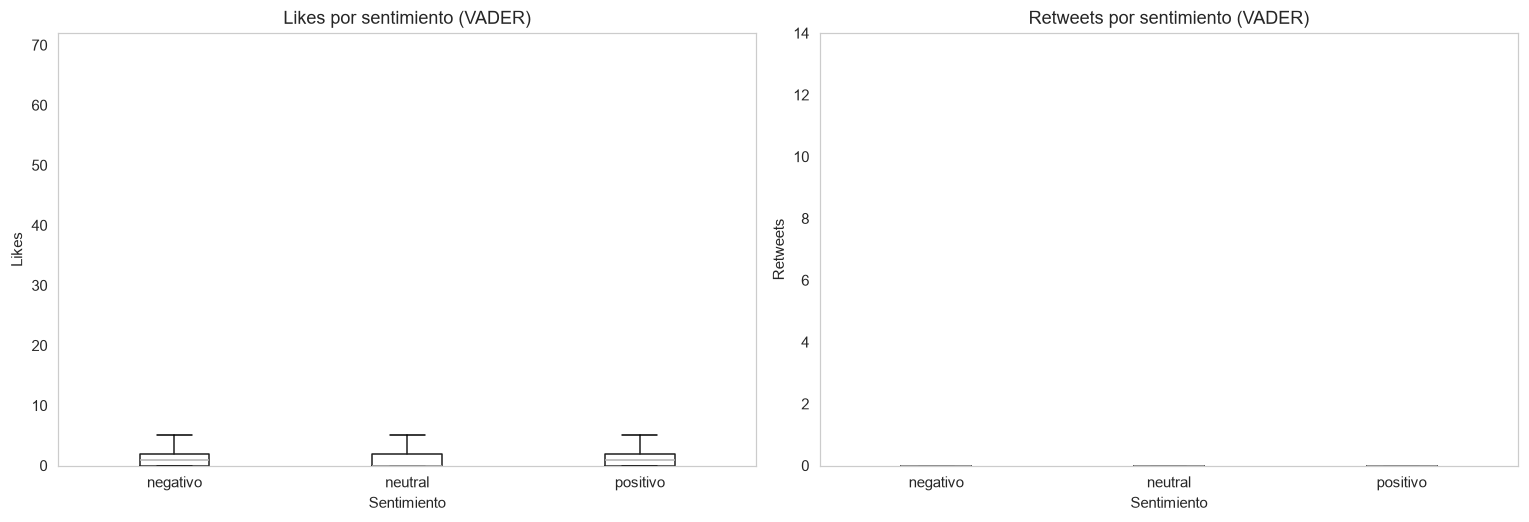

✅ Guardado: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\outputs\figuras\04_sentimiento_engagement.png

📊 Estadísticas por sentimiento:
                       n  like_medio  rt_medio  compound_medio
sentimiento_vader                                             
negativo           16062        7.23      1.19           -0.41
neutral            30678        5.82      0.90            0.00
positivo           53260        9.49      1.96            0.53


In [14]:
# ============================================
# Sentimiento vs engagement (likes, retweets)
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Likes por sentimiento (recortado a 100 para visualización)
df.boxplot(
    column="like_count", by="sentimiento_vader",
    ax=axes[0], showfliers=False, grid=False,
)
axes[0].set_title("Likes por sentimiento (VADER)")
axes[0].set_xlabel("Sentimiento")
axes[0].set_ylabel("Likes")
axes[0].set_ylim(0, min(100, df["like_count"].quantile(0.99)))

# Retweets por sentimiento
df.boxplot(
    column="retweet_count", by="sentimiento_vader",
    ax=axes[1], showfliers=False, grid=False,
)
axes[1].set_title("Retweets por sentimiento (VADER)")
axes[1].set_xlabel("Sentimiento")
axes[1].set_ylabel("Retweets")
axes[1].set_ylim(0, min(50, df["retweet_count"].quantile(0.99)))

plt.suptitle("")
plt.tight_layout()
ruta_fig = FIGURAS / "04_sentimiento_engagement.png"
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Guardado: {ruta_fig}")

# Estadísticas
print("\n📊 Estadísticas por sentimiento:")
stats = df.groupby("sentimiento_vader").agg(
    n=("vader_compound", "count"),
    like_medio=("like_count", "mean"),
    rt_medio=("retweet_count", "mean"),
    compound_medio=("vader_compound", "mean"),
).round(2)
print(stats)

In [15]:
# ============================================
# Top tweets más positivos y más negativos
# ============================================
print("🟢 TOP 5 TWEETS MÁS POSITIVOS (VADER):\n")
top_pos = df.nlargest(5, "vader_compound")[["texto_limpio", "vader_compound", "like_count"]]
for _, row in top_pos.iterrows():
    print(f"  [{row['vader_compound']:+.2f}] {row['texto_limpio'][:150]}...")
    print(f"     ❤️ {int(row['like_count'])}\n")

print("\n🔴 TOP 5 TWEETS MÁS NEGATIVOS (VADER):\n")
top_neg = df.nsmallest(5, "vader_compound")[["texto_limpio", "vader_compound", "like_count"]]
for _, row in top_neg.iterrows():
    print(f"  [{row['vader_compound']:+.2f}] {row['texto_limpio'][:150]}...")
    print(f"     ❤️ {int(row['like_count'])}\n")

🟢 TOP 5 TWEETS MÁS POSITIVOS (VADER):

  [+1.00] do we need more ai tools yes yes yes yes yesyes yes yes yes yes yes yes yes yes yes yesyes yes yes yes yesye yes yes yes yes yes yes chatgpt aitools...
     ❤️ 0

  [+0.99] i love technology i love ai i love andrew tate i love influencers and tiktok and youtube shorts i also love nfts and smart contracts i love politics a...
     ❤️ 5

  [+0.99] learning youtube free google free bing free blogs free ideas chat gpt free discord free linkldn free reddit free money kick starter free building gith...
     ❤️ 1

  [+0.99] chatgpt is free youtube is free notion is free facebook is free gumroad is free twitter is free google is free hypefury is free docs is free canva is ...
     ❤️ 3

  [+0.99] chatgpt is free twitter is free google is free github is free youtube is free clickup is free courses are free canva is free mint is free podcasts are...
     ❤️ 2


🔴 TOP 5 TWEETS MÁS NEGATIVOS (VADER):

  [-1.00] i hate chat gpt i hate chat gpt i hate

In [16]:
# ============================================
# Guardar corpus con sentimiento
# ============================================
timestamp = datetime.now().strftime("%Y%m%d")
ruta_out = DATA_PROCESSED / f"tweets_con_sentimiento_{timestamp}.csv"

cols_salida = [
    "date", "fecha", "username", "texto_limpio", "idioma",
    "tokens", "lemas",
    "tb_polarity", "tb_subjectivity",
    "vader_pos", "vader_neu", "vader_neg", "vader_compound",
    "sentimiento_textblob", "sentimiento_vader",
    "like_count", "retweet_count",
]
cols_salida = [c for c in cols_salida if c in df.columns]

df[cols_salida].to_csv(ruta_out, index=False, encoding="utf-8-sig")
print(f"✅ Guardado: {ruta_out}")
print(f"📊 Shape: {df.shape}")

# Guardar también el ground truth con predicciones
if df_sent is not None:
    ruta_sent_out = DATA_PROCESSED / f"sentiment_labels_con_pred_{timestamp}.csv"
    df_sent.to_csv(ruta_sent_out, index=False, encoding="utf-8-sig")
    print(f"✅ Guardado: {ruta_sent_out}")

✅ Guardado: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\data\processed\tweets_con_sentimiento_20260920.csv
📊 Shape: (100000, 16)


In [17]:
# ============================================
# Resumen ejecutivo (para el informe)
# ============================================
lineas = []
lineas.append("# Notebook 04 — NLP y análisis de sentimiento\n")
lineas.append(f"**Fecha:** {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
lineas.append(f"**Tweets analizados:** {len(df):,}\n")
lineas.append(f"\n## Distribución de sentimiento (VADER)\n")
lineas.append(df["sentimiento_vader"].value_counts().to_string())
lineas.append(f"\n\n## Sentimiento medio (VADER compound): {df['vader_compound'].mean():.4f}")
lineas.append(f"\n## Polaridad media (TextBlob): {df['tb_polarity'].mean():.4f}")

if "idioma" in df.columns:
    lineas.append(f"\n\n## Sentimiento por idioma\n")
    lineas.append(
        df.groupby("idioma")["vader_compound"].agg(["mean", "count"]).round(3).to_string()
    )

if df_sent is not None:
    lineas.append(f"\n\n## Validación contra ground truth\n")
    lineas.append(f"- **TextBlob Accuracy:** {accuracy_score(y_true, y_tb):.3f}")
    lineas.append(f"- **VADER Accuracy:** {accuracy_score(y_true, y_vader):.3f}")

reporte = "\n".join(lineas)
ruta_reporte = REPORTES / f"04_sentimiento_resumen_{timestamp}.md"
ruta_reporte.write_text(reporte, encoding="utf-8")
print(f"✅ Reporte guardado: {ruta_reporte}\n")
print(reporte[:1500])

✅ Reporte guardado: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\outputs\reportes\04_sentimiento_resumen_20260920.md

# Notebook 04 — NLP y análisis de sentimiento

**Fecha:** 2026-09-20 17:24

**Tweets analizados:** 100,000


## Distribución de sentimiento (VADER)

sentimiento_vader
positivo    53260
neutral     30678
negativo    16062


## Sentimiento medio (VADER compound): 0.2174

## Polaridad media (TextBlob): 0.1167
